In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
import src.dca as dca
import importlib
importlib.reload(dca)

from src.dca import fit_decline_model, forecast_production, calculate_eur

In [4]:
df = pd.read_csv("../data/processed/oil_well_clean.csv")

In [5]:
df.head()

,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
0,2013-01-01,49.0,70.0,13055.0,21.0,29.0,24.0,1819.0,214.0
1,2013-01-02,49.0,70.0,13055.0,21.0,29.0,24.0,1836.0,214.0
2,2013-01-03,49.0,70.0,13055.0,21.0,29.0,24.0,1788.0,214.0
3,2013-01-04,49.0,70.0,13055.0,21.0,29.0,24.0,1789.0,214.0
4,2013-01-05,44.0,70.0,11768.0,26.0,36.0,24.0,1825.0,214.0


In [7]:
wells = ["Well A", "Well B", "Well C"]
dfs = []

for well in wells:
    temp = df.copy()

    decline_factor = np.random.uniform(0.0003, 0.001)
    scale_factor = np.random.uniform(0.6, 1.4)

    noise = np.random.normal(1, 0.1, size=len(temp))

    temp["oil_volume"] = temp["oil_volume"] * noise * scale_factor
    temp["oil_volume"] = temp["oil_volume"] * np.exp(-decline_factor * np.arange(len(temp)))

    temp["well_id"] = well

    dfs.append(temp)

df_field = pd.concat(dfs).reset_index(drop=True)

df_field["date"] = pd.to_datetime(df_field["date"])

In [8]:
well_summary = df_field.groupby("well_id").agg({
    "oil_volume": ["mean", "max", "sum"],
    "water_cut": "mean",
    "reservoir_pressure": "mean"
}).reset_index()

In [9]:
well_summary.columns = [
    "well_id",
    "oil_mean",
    "oil_max",
    "oil_cumulative",
    "water_cut_mean",
    "pressure_mean"
]

well_summary

,well_id,oil_mean,oil_max,oil_cumulative,water_cut_mean,pressure_mean
0,Well A,11.484087,71.036841,33763.215489,70.692517,157.026871
1,Well B,6.961373,44.430832,20466.436042,70.692517,157.026871
2,Well C,8.697016,59.264810,25569.227448,70.692517,157.026871


In [10]:
results_list = []
future_days = 365 * 2

for well in df_field["well_id"].unique():
    df_well = df_field[df_field["well_id"] == well]
    
    df_well = df_well.sort_values("date")

    oil = df_well["oil_volume"].rolling(7, min_periods = 1).mean()
    
    t = np.arange(len(oil))
    
    q = oil.values
    
    fit_results = fit_decline_model(t, q)
    
    forecast = forecast_production(t, q, fit_results, future_days)
    
    eur = calculate_eur(q, forecast["q_forecast"])
    
    results_list.append({
        "well_id": well,
        "model": fit_results["model"],
        "rmse": min(fit_results["rmse_exp"], fit_results["rmse_hyp"]),
        "eur": eur
    })

df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values("eur", ascending=False)
df_results["tier"] = pd.qcut(df_results["eur"], q=3, labels=["Low", "Mid", "Top"])
order = df_results["well_id"]
    
df_results

d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)


,well_id,model,rmse,eur,tier
0,Well A,Hyperbolic,2.442463,35016.144292,Top
2,Well C,Hyperbolic,1.835062,26360.614279,Mid
1,Well B,Hyperbolic,1.508246,21114.372287,Low


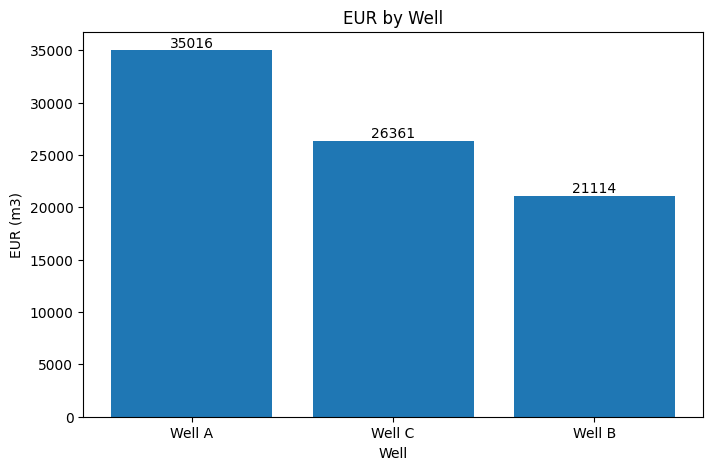

In [11]:
plt.figure(figsize=(8,5))
plt.bar(df_results["well_id"], df_results["eur"])

plt.title("EUR by Well")
plt.xlabel("Well")
plt.ylabel("EUR (m3)")

for i, v in enumerate(df_results["eur"]):
    plt.text(i, v, f"{v:.0f}", ha="center", va="bottom")

plt.savefig("../outputs/figures/eur_wells.png")
plt.show()

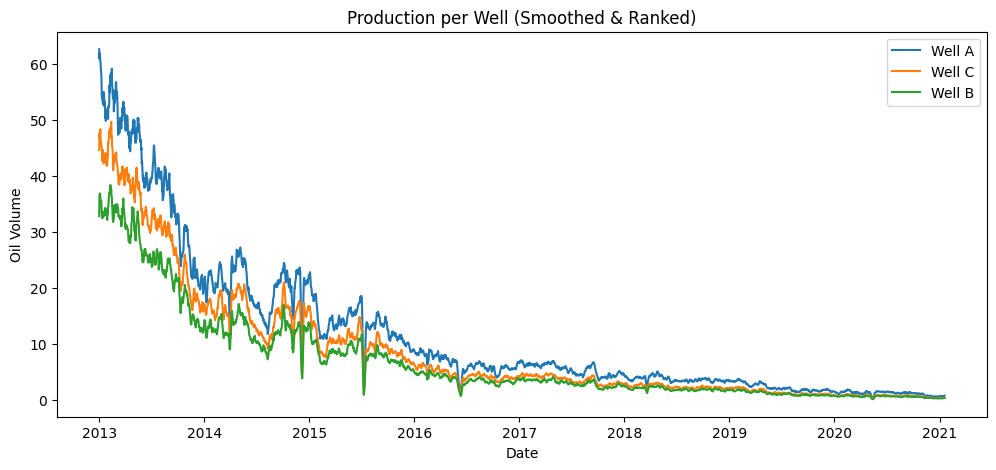

In [12]:
plt.figure(figsize=(12,5))

for well in order:  # 👈 usamos ranking
    
    df_well = df_field[df_field["well_id"] == well]
    
    df_well = df_well.sort_values("date")
    
    oil_smooth = df_well["oil_volume"].rolling(7, min_periods=1).mean()
    
    plt.plot(df_well["date"], oil_smooth, label=well)

plt.legend()
plt.title("Production per Well (Smoothed & Ranked)")
plt.xlabel("Date")
plt.ylabel("Oil Volume")

plt.savefig("../outputs/figures/production_by_well.png")
plt.show()

d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)


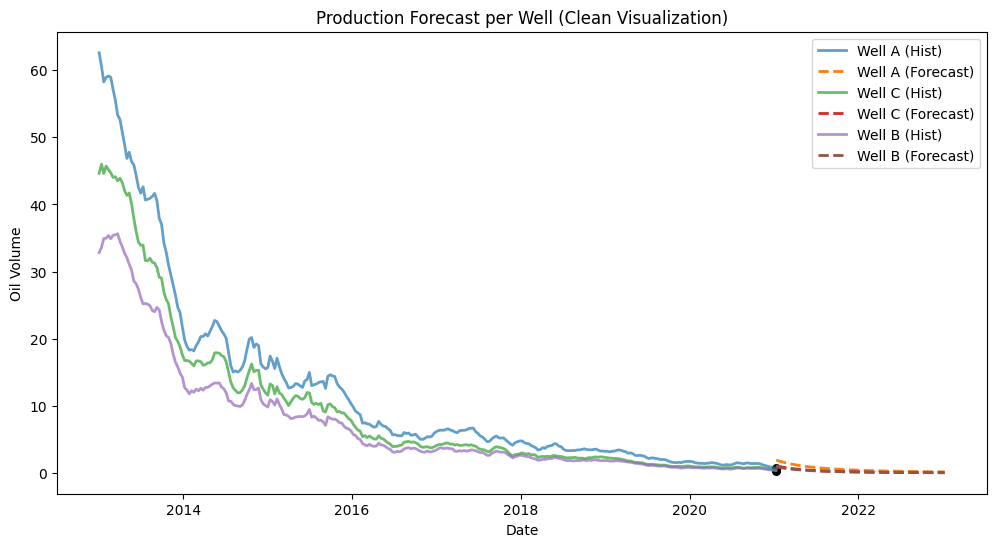

In [13]:
plt.figure(figsize=(12,6))

future_days = 365 * 2
order = df_results["well_id"]

for well in order:

    df_well = df_field[df_field["well_id"] == well].copy()
    df_well = df_well.sort_values("date").reset_index(drop=True)

    df_well_sampled = df_well.iloc[::10]  # 1 de cada 10 puntos

    oil = df_well_sampled["oil_volume"].rolling(7, min_periods=1).mean()

    t = np.arange(len(oil))
    q = oil.values

    fit_results = fit_decline_model(t, q)
    forecast = forecast_production(t, q, fit_results, future_days)

    last_date = df_well_sampled["date"].iloc[-1]

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=future_days,
        freq="D"
    )

    plt.plot(
        df_well_sampled["date"],
        q,
        alpha=0.7,
        linewidth=2,
        label=f"{well} (Hist)"
    )

    plt.scatter(last_date, q[-1], color="black", s=30)

    plt.plot(
        future_dates,
        forecast["q_forecast"],
        linestyle="--",
        linewidth=2,
        label=f"{well} (Forecast)"
    )

plt.legend()
plt.title("Production Forecast per Well (Clean Visualization)")
plt.xlabel("Date")
plt.ylabel("Oil Volume")

plt.savefig("../outputs/figures/forecast_per_well.png")
plt.show()

d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)


Well A reaches economic limit at 2021-01-10
Well C reaches economic limit at 2021-01-10
Well B reaches economic limit at 2021-01-10


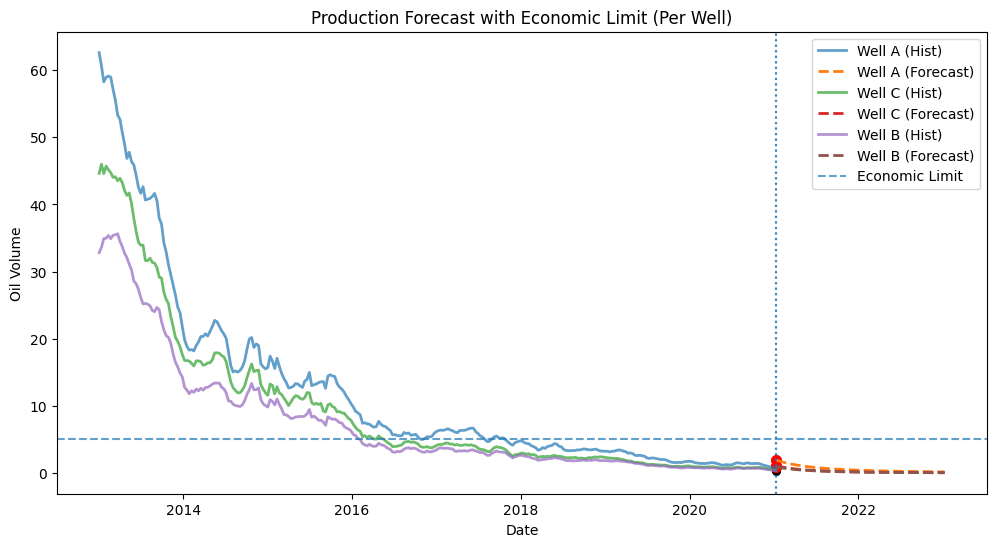

In [14]:
plt.figure(figsize=(12,6))

future_days = 365 * 2
ECONOMIC_LIMIT = 5

order = df_results["well_id"]

for well in order:

    df_well = df_field[df_field["well_id"] == well].copy()
    df_well = df_well.sort_values("date").reset_index(drop=True)

    df_well_sampled = df_well.iloc[::10]

    oil = df_well_sampled["oil_volume"].rolling(7, min_periods=1).mean()

    t = np.arange(len(oil))
    q = oil.values

    fit_results = fit_decline_model(t, q)
    forecast = forecast_production(t, q, fit_results, future_days)

    q_forecast = forecast["q_forecast"]

    last_date = df_well_sampled["date"].iloc[-1]

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=future_days,
        freq="D"
    )

    plt.plot(
        df_well_sampled["date"],
        q,
        alpha=0.7,
        linewidth=2,
        label=f"{well} (Hist)"
    )

    plt.scatter(last_date, q[-1], color="black", s=30)

    # 🔴 forecast
    plt.plot(
        future_dates,
        q_forecast,
        linestyle="--",
        linewidth=2,
        label=f"{well} (Forecast)"
    )

    below_limit_idx = np.where(q_forecast < ECONOMIC_LIMIT)[0]

    if len(below_limit_idx) > 0:
        idx = below_limit_idx[0]
        econ_date = future_dates[idx]
        econ_value = q_forecast[idx]

        plt.scatter(econ_date, econ_value, color="red", s=50)

        plt.axvline(econ_date, linestyle=":", alpha=0.5)

        print(f"{well} reaches economic limit at {econ_date.date()}")

    else:
        print(f"{well} does NOT reach economic limit")

plt.axhline(ECONOMIC_LIMIT, linestyle="--", alpha=0.7, label="Economic Limit")

plt.legend()
plt.title("Production Forecast with Economic Limit (Per Well)")
plt.xlabel("Date")
plt.ylabel("Oil Volume")

plt.savefig("../outputs/figures/forecast_with_economic_limit.png")
plt.show()

In [15]:
df_results.to_csv("../outputs/data/well_summary.csv", index=False)

In [16]:
df_field.to_csv("../outputs/data/production_data.csv", index=False)

In [17]:
forecast_rows = []

future_days = 365 * 2

for well in df_field["well_id"].unique():
    
    df_well = df_field[df_field["well_id"] == well].copy()
    df_well = df_well.sort_values("date")

    oil = df_well["oil_volume"].rolling(7, min_periods=1).mean()
    t = np.arange(len(oil))
    q = oil.values

    fit_results = fit_decline_model(t, q)
    forecast = forecast_production(t, q, fit_results, future_days)

    last_date = df_well["date"].iloc[-1]

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=future_days,
        freq="D"
    )

    for date, value in zip(future_dates, forecast["q_forecast"]):
        forecast_rows.append({
            "well_id": well,
            "date": date,
            "oil_volume": value,
            "type": "forecast"
        })

df_forecast = pd.DataFrame(forecast_rows)

d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-D * t)
d:\IT\oil-well-production-analysis\src\dca.py:13: RuntimeWarning: overflow encountered in multiply
  return qi * np.exp(-D * t)


In [18]:
df_hist = df_field.copy()
df_hist["type"] = "historical"

df_forecast = pd.DataFrame(forecast_rows)

df_combined = pd.concat([df_hist, df_forecast])

df_combined["date"] = pd.to_datetime(df_combined["date"])
df_combined = df_combined.sort_values(["well_id", "date"])
df_combined = df_combined.reset_index(drop=True)

df_combined.to_csv("../outputs/data/combined_production.csv", index=False)